# Eignungsprüfung: HBSC-Datensatz (Alkoholkonsum vs. Sport bei Jugendlichen)

Dieses Notebook prüft, ob die **HBSC-Daten** (*Health Behaviour in School-aged Children*, 5 Erhebungswellen 2001–2018)
für die Aufgabe *Data Exploration* tauglich sind. Der inhaltliche Schwerpunkt ist der **Vergleich von Alkoholkonsum und
sportlicher Aktivität** – inklusive erster Visualisierungen dazu.
Es folgt der Struktur von `Template_DataExploration.ipynb` (Fragen 1–4, 8, 9) und endet mit einem Fazit.
Die eigentliche Abgabe (Fragen 5–7, 10, 11) wird im Template ausgearbeitet.

## 1) Datensatz laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# Pro Welle eine Datei - Trennzeichen, Gross-/Kleinschreibung und Variablennamen unterscheiden sich!
FILES = {2001: "data/HBSC2001OAed1.0_F4.csv",
         2006: "data/HBSC2006OAed1.0_F1.csv",
         2010: "data/HBSC2010OAed1.0_F4.csv",
         2014: "data/HBSC2014OAed1.1_F1.csv",
         2018: "data/HBSC2018OAed1.1.csv"}       # 2018: Semikolon + BOM

raw = {}
for year, path in FILES.items():
    df = pd.read_csv(path, sep=";" if year == 2018 else ",", encoding="utf-8-sig", low_memory=False)
    df.columns = df.columns.str.lower()            # 2014 hat GROSSGESCHRIEBENE Namen
    raw[year] = df

raw[2001].iloc[:3, :12]

,surveyyear,countryno,subregion,schoolno,classno,uniqueid,sampleweights,monhtcollect,yearcollect,sex,grade,monthbirth
0,2002,40000,NaN,400001.0,400001.0,400001001.0,1.0,10,2001,2,1,11.0
1,2002,40000,NaN,400001.0,400001.0,400001002.0,1.0,10,2001,2,1,12.0
2,2002,40000,NaN,400001.0,400001.0,400001003.0,1.0,10,2001,1,1,2.0


## 2) Kurzbeschreibung & Quelle

**Inhalt:** Schülerbefragung der WHO-Studie *Health Behaviour in School-aged Children* (HBSC) unter 11-, 13- und
15-Jährigen in Europa und Nordamerika. Pro Zeile eine befragte Person mit rund 120–170 Fragen zu Ernährung, Bewegung,
Medienkonsum, Rauchen, **Alkohol**, Cannabis, Wohlbefinden, Schule u. a. Die Studie läuft alle 4 Jahre; vorliegend sind die
**Open-Access-Versionen** der Wellen 2001/02, 2006, 2010, 2014 und 2018 (je ein Codebuch als PDF im Ordner `data/`).

**Quelle:** HBSC Data Management Centre (Universität Bergen), Open-Access-Datensätze; Details und Nutzungsbedingungen in den
beiliegenden Codebüchern (`HBSC20xxOAed*.pdf`).

**Für den Vergleich verwendete Kernvariablen** (in allen 5 Wellen mit gleicher Skala vorhanden):

| Thema | Variable | Frage | Skala |
|---|---|---|---|
| Sport | `physact60` | An wie vielen der letzten 7 Tage warst du mind. 60 Min. körperlich aktiv? | 0–7 Tage |
| Alkohol | `drunk` (2018: `drunkltm`) | Schon einmal so viel Alkohol, dass du richtig betrunken warst? | 1 = nie … 5 = >10-mal |
| Alkohol (ergänzend) | `alc30d_2` (2014, 2018) bzw. `drink30d` (2010) | Alkohol an wie vielen Tagen in den letzten 30 Tagen? | 1 = nie … 7 = ≥30 Tage |
| Kontext | `sex`, `age`, `agecat`, `countryno` | Geschlecht, Alter, Altersgruppe (11/13/15), Land | – |

## 3) Größe des Datensatzes (Zeilen / Spalten)

In [2]:
groesse = pd.DataFrame({y: {"Zeilen (Befragte)": d.shape[0], "Spalten": d.shape[1],
                            "Länder/Regionen": d.countryno.nunique()} for y, d in raw.items()}).T
print(groesse.to_string())
print("\nGesamt:", f"{groesse['Zeilen (Befragte)'].sum():,}".replace(",", "."), "Befragte")

gemeinsam = set.intersection(*[set(d.columns) for d in raw.values()])
print(f"\nIn allen 5 Wellen gleich benannte Spalten: {len(gemeinsam)}")
print(sorted(gemeinsam))

      Zeilen (Befragte)  Spalten  Länder/Regionen
2001             162305      127               35
2006             205938      124               41
2010             213595      128               40
2014             214080      170               41
2018             244097      120               47

Gesamt: 1.040.015 Befragte

In allen 5 Wellen gleich benannte Spalten: 44
['age', 'agecat', 'agesex', 'backache', 'beenbullied', 'bodyheight', 'bodyweight', 'breakfastwd', 'breakfastwe', 'bulliedothers', 'contraceptcondom', 'contraceptpill', 'countryno', 'dizzy', 'fatherhome1', 'feellow', 'fight12m', 'fosterhome1', 'hadsex', 'headache', 'health', 'injured12m', 'irritable', 'lifesat', 'likeschool', 'monthbirth', 'motherhome1', 'nervous', 'physact60', 'schoolpressure', 'sex', 'stepfahome1', 'stepmohome1', 'stomachache', 'studaccept', 'studhelpful', 'studtogether', 'talkfather', 'talkmother', 'talkstepfa', 'talkstepmo', 'thinkbody', 'toothbr', 'yearbirth']


Der Datensatz ist mit **rund 1 Mio. Zeilen** (Summe der fünf Wellen) sehr groß; für die Visualisierung wird deshalb
aggregiert (Anteile, Mittelwerte je Land/Gruppe) statt Einzelpunkte zu zeichnen.
Nur ein kleiner Teil der Spalten ist über alle Wellen hinweg gleich benannt – die Variablen müssen **harmonisiert** werden (siehe Abschnitt 4).

**Relevante Spalten** (multivariat, > 10 auswertbare Attribute):
`surveyyear`, `countryno`, `sex`, `age`/`agecat`, `physact60`, `drunk`, `alc30d`, dazu optional `fruits`, `softdrinks`,
`tvwd`, `smoking`, `lifesat`, `health`. Rund 100 weitere Spalten (Schulklima, Sexualverhalten, Familienwohlstand …)
werden für die Fragestellung nicht benötigt.

## 4) Harmonisierung, fehlende Werte & Datenqualität

### Problem 1: Uneinheitliche Struktur der Wellen

In [3]:
namen = {"physact60": "physact60", "drunk": "drunk", "drink30d": "drink30d", "alc30d_2": "alc30d_2",
         "alcltm": "alcltm", "alcofreq": "alcofreq", "sampleweights": "sampleweights", "weight": "weight"}
vorhanden = pd.DataFrame({y: {v: (k in d.columns) for k, v in namen.items()} for y, d in raw.items()})
vorhanden.loc["drunk (2018: drunkltm)"] = [("drunk" in d.columns) or ("drunkltm" in d.columns) for d in raw.values()]
print(vorhanden.replace({True: "ja", False: "-"}).to_string())

print("\nDatentypen der Kernvariablen 2018 (alle 'object', weil leere Felder als ' ' gespeichert sind):")
print(raw[2018][["physact60", "drunkltm", "alc30d_2", "agecat", "age"]].dtypes.to_string())
print("\nUngültige Codes 2018 (-99 = 'Missing due to inconsistent answer'):",
      (raw[2018].drunkltm.astype(str).str.strip() == "-99").sum(), "Zeilen bei drunkltm")

                       2001 2006 2010 2014 2018
physact60                ja   ja   ja   ja   ja
drunk                    ja   ja   ja   ja    -
drink30d                  -    -   ja    -    -
alc30d_2                  -    -    -   ja   ja
alcltm                    -    -    -   ja   ja
alcofreq                 ja    -    -    -    -
sampleweights            ja   ja   ja    -    -
weight                    -    -    -    -   ja
drunk (2018: drunkltm)   ja   ja   ja   ja   ja

Datentypen der Kernvariablen 2018 (alle 'object', weil leere Felder als ' ' gespeichert sind):
physact60    str
drunkltm     str
alc30d_2     str
agecat       str
age          str

Ungültige Codes 2018 (-99 = 'Missing due to inconsistent answer'): 697 Zeilen bei drunkltm


**Befund:** Trennzeichen (`,` vs. `;`), Zeichenkodierung (BOM in 2018), Groß-/Kleinschreibung (2014) und Variablennamen
(`drunk` vs. `drunkltm`, `drink30d` vs. `alc30d_2`) unterscheiden sich; 2018 enthält leere Felder als Leerzeichen und den
Sondercode `-99`. Ohne Bereinigung würden 2018-Werte als Text eingelesen; das Alter (Dezimalkomma, z. B. 13,5) ginge beim Umwandeln zu 91 % verloren.

### Bereinigung (Vorschlag)

In [4]:
LAENDER = {8000: "Albania", 31000: "Azerbaijan", 40000: "Austria", 51000: "Armenia", 56001: "Belgium (Flemish)",
           56002: "Belgium (French)", 100000: "Bulgaria", 124000: "Canada", 191000: "Croatia", 203000: "Czech Republic",
           208000: "Denmark", 233000: "Estonia", 246000: "Finland", 250000: "France", 268000: "Georgia",
           276000: "Germany", 300000: "Greece", 304000: "Greenland", 348000: "Hungary", 352000: "Iceland",
           372000: "Ireland", 376000: "Israel", 380000: "Italy", 398000: "Kazakhstan", 428000: "Latvia",
           440000: "Lithuania", 442000: "Luxembourg", 470000: "Malta", 498000: "Moldova", 528000: "Netherlands",
           578000: "Norway", 616000: "Poland", 620000: "Portugal", 642000: "Romania", 643000: "Russia",
           688000: "Serbia", 703000: "Slovakia", 705000: "Slovenia", 724000: "Spain", 752000: "Sweden",
           756000: "Switzerland", 792000: "Turkey", 804000: "Ukraine", 807000: "North Macedonia",
           826001: "England", 826002: "Scotland", 826003: "Wales", 840000: "USA"}

def num(s, ungueltig=(-99,)):
    """Text -> Zahl, Leerzeichen und Sondercodes -> NaN"""
    s = pd.to_numeric(s.astype(str).str.replace(",", "."), errors="coerce")   # 2018: Dezimalkomma
    return s.where(~s.isin(ungueltig))

def harmonisieren(year, d):
    out = pd.DataFrame({"year": year,
                        "country": d.countryno.map(LAENDER),
                        "sex": num(d.sex).map({1: "Junge", 2: "Mädchen"}),
                        "age": num(d.age),
                        "agecat": num(d.agecat),
                        "sport_days": num(d.physact60),                     # 0-7
                        "drunk_lifetime": num(d.drunk if "drunk" in d else d.drunkltm)})   # 1-5
    d30 = next((c for c in ["alc30d_2", "drink30d"] if c in d.columns), None)
    out["alc_30d"] = num(d[d30]) if d30 else np.nan                        # 1-7 (erst ab 2010)
    return out

hbsc = pd.concat([harmonisieren(y, d) for y, d in raw.items()], ignore_index=True)
# Ableitungen fuer die Visualisierung
hbsc["drunk_ever"]   = (hbsc.drunk_lifetime > 1).astype(float).where(hbsc.drunk_lifetime.notna())   # 1.0 / 0.0
hbsc["sport_gruppe"] = pd.cut(hbsc.sport_days, [-1, 2, 4, 6, 7],
                              labels=["0-2 Tage", "3-4 Tage", "5-6 Tage", "täglich (7)"])
print("Zeilen:", len(hbsc), "| ungemappte Länder:", hbsc.country.isna().sum(),
      "| Länder gesamt:", hbsc.country.nunique())
hbsc.sample(4, random_state=1)

Zeilen: 1040015 | ungemappte Länder: 0 | Länder gesamt: 48


,year,country,sex,age,agecat,sport_days,drunk_lifetime,alc_30d,drunk_ever,sport_gruppe
925341,2018,Iceland,Mädchen,11.250000,1.0,0.0,1.0,1.0,0.0,0-2 Tage
797256,2018,Albania,Junge,10.833333,1.0,7.0,2.0,NaN,1.0,täglich (7)
151811,2001,Scotland,Mädchen,11.083333,1.0,6.0,2.0,NaN,1.0,5-6 Tage
214837,2006,France,Mädchen,11.666667,1.0,5.0,1.0,NaN,0.0,5-6 Tage


### Problem 2: Fehlende Werte

In [5]:
kern = ["sport_days", "drunk_lifetime", "alc_30d", "sex", "age", "agecat"]
print("Fehlende Werte je Welle (%):")
print(hbsc.groupby("year")[kern].apply(lambda g: g.isna().mean().mul(100).round(1)).to_string())
print("\nGesamt (%):"); print((hbsc[kern].isna().mean()*100).round(1).to_string())

both = hbsc.dropna(subset=["sport_days", "drunk_lifetime"])
print(f"\nPersonen mit BEIDEN Angaben (Sport + Betrunkenheit): {len(both):,} von {len(hbsc):,} ({len(both)/len(hbsc):.1%})".replace(",", "."))

Fehlende Werte je Welle (%):
      sport_days  drunk_lifetime  alc_30d  sex  age  agecat
year                                                       
2001         4.8             0.9    100.0  0.0  0.8     0.8
2006         2.5             8.9    100.0  0.0  0.7     0.7
2010         2.3             5.7     24.1  0.0  1.0     1.0
2014         2.8             4.2      5.8  0.0  0.9     0.9
2018         2.5             8.2      7.9  0.0  0.6     0.6

Gesamt (%):
sport_days         2.9
drunk_lifetime     5.9
alc_30d           43.4
sex                0.0
age                0.8
agecat             0.8

Personen mit BEIDEN Angaben (Sport + Betrunkenheit): 954.696 von 1.040.015 (91.8%)


### Problem 3: Ändern sich Länder, Alter und Fragebogen zwischen den Wellen?

In [6]:
print("Länder pro Welle:", hbsc.groupby("year").country.nunique().to_dict())
print("Länder, die in ALLEN Wellen vorkommen:", hbsc.groupby("country").year.nunique().eq(5).sum())
print("\nAlter (min/max) und Anteil je Altersgruppe:")
print(hbsc.groupby("year").agg(alter_min=("age", "min"), alter_max=("age", "max"),
                                mittel=("age", "mean")).round(1).to_string())
print(pd.crosstab(hbsc.year, hbsc.agecat, normalize="index").round(2).rename(
      columns={1: "11 J.", 2: "13 J.", 3: "15 J."}).to_string())
print("\nGeschlechterverhältnis (Anteil Mädchen):",
      hbsc.groupby("year").sex.apply(lambda s: (s == "Mädchen").mean()).round(3).to_dict())

Länder pro Welle: {2001: 35, 2006: 41, 2010: 40, 2014: 41, 2018: 47}
Länder, die in ALLEN Wellen vorkommen: 32

Alter (min/max) und Anteil je Altersgruppe:
      alter_min  alter_max  mittel
year                              
2001        9.8       17.2    13.5
2006       10.5       16.6    13.6
2010       10.5       16.5    13.6
2014       10.5       16.5    13.6
2018       10.0       16.5    13.5


agecat  11 J.  13 J.  15 J.
year                       
2001     0.34   0.35   0.31
2006     0.33   0.34   0.33
2010     0.32   0.34   0.34
2014     0.32   0.35   0.33
2018     0.34   0.35   0.32



Geschlechterverhältnis (Anteil Mädchen): {2001: 0.514, 2006: 0.509, 2010: 0.508, 2014: 0.508, 2018: 0.507}


**Zusammenfassung Datenqualität:**

| Problem | Ursache | Umgang |
|---|---|---|
| 5 Dateien mit unterschiedlichem Format (`,`/`;`, BOM, Groß-/Kleinschreibung) | getrennte Erhebungswellen | einheitlich einlesen, Spalten `lower()` |
| Variablen heißen je Welle anders (`drunk`/`drunkltm`, `drink30d`/`alc30d_2`) | Codebuch-Änderungen | Mapping in `harmonisieren()` |
| 2018: leere Felder als `' '`, Sondercode `-99`, Alter mit Dezimalkomma | Export-Format | `pd.to_numeric(errors="coerce")`, `-99` → NaN |
| `alc_30d` nur ab 2010 vorhanden | Frage in 2001/2006 anders gestellt (`alcofreq`) | 30-Tage-Alkohol nur 2010–2018 vergleichen; für alle Wellen `drunk_lifetime` nutzen |
| `drunk` in 2006 zu ~9 % fehlend, in Spanien und der Türkei 2006 zu 100 % fehlend | Frage in manchen Ländern nicht gestellt | Länder-Auswertungen nur mit gültigen Werten, Fallzahl je Land prüfen |
| Ländermenge wechselt (35 → 47 Länder) | Teilnahme der Länder ändert sich | für Zeitvergleiche auf Länder mit allen Wellen einschränken |
| Gewichte (`sampleweights`/`weight`) nicht in allen Wellen vorhanden | unterschiedliche Stichprobenpläne | Auswertung ungewichtet; Aussagen gelten für die Stichprobe, nicht für die Bevölkerung |
| Skala `physact60` zählt Tage (0–7), nicht Minuten | Fragebogendesign | in Gruppen (0–2 / 3–4 / 5–6 / 7 Tage) zusammenfassen |

## 8) Attributtypen

In [7]:
print("QUANTITATIV / ORDINAL (Wertebereich):")
for c in ["year", "age", "sport_days", "drunk_lifetime", "alc_30d"]:
    print(f"  {c:16s} min={hbsc[c].min():6.1f}  max={hbsc[c].max():6.1f}  gültig={hbsc[c].notna().sum():>8,}".replace(",", "."))
print("\nNOMINAL (Anzahl eindeutiger Klassen):")
for c in ["country", "sex"]:
    print(f"  {c:16s} {hbsc[c].nunique():3d} Klassen")
print("  agecat (ordinal)", sorted(hbsc.agecat.dropna().unique()))

QUANTITATIV / ORDINAL (Wertebereich):
  year             min=2001.0  max=2018.0  gültig=1.040.015
  age              min=   9.8  max=  17.2  gültig=1.031.863
  sport_days       min=   0.0  max=   7.0  gültig=1.009.968
  drunk_lifetime   min=   1.0  max=   5.0  gültig= 979.105
  alc_30d          min=   1.0  max=   7.0  gültig= 588.511

NOMINAL (Anzahl eindeutiger Klassen):
  country           48 Klassen
  sex                2 Klassen
  agecat (ordinal) [np.float64(1.0), np.float64(2.0), np.float64(3.0)]


| Spalte | Typ | Wertebereich / Klassen |
|---|---|---|
| `year` | quantitativ (diskret), **temporal** | 2001, 2006, 2010, 2014, 2018 |
| `country` | nominal, **geografisch** | 48 Länder/Regionen insgesamt (35–47 je Welle) |
| `sex` | nominal | 2 Klassen (Junge, Mädchen) |
| `agecat` / `age` | **ordinal** bzw. quantitativ | 11 / 13 / 15 Jahre bzw. ca. 10–17 |
| `sport_days` (`physact60`) | quantitativ (diskret, ratio) | 0–7 Tage mit ≥ 60 Min. Aktivität |
| `drunk_lifetime` (`drunk`) | **ordinal** | 1 = nie, 2 = einmal, 3 = 2–3×, 4 = 4–10×, 5 = >10× |
| `alc_30d` | **ordinal** | 1 = nie … 7 = ≥ 30 Tage (nur 2010–2018) |

## 9) Weitere semantische Strukturen

In [8]:
print("TEMPORAL    : 5 Erhebungswellen (2001-2018), Trend je Land und Altersgruppe möglich")
print("GEOGRAFISCH :", hbsc.country.nunique(), "Länder/Regionen -> Karte / Choropleth nutzbar (Ländercode = ISO-3166-Zahl x 1000)")
print("HIERARCHISCH: Land > Schule > Klasse > Schüler:in (Spalten countryno, schoolno/id, classno)")
print("KATEGORIAL  : Geschlecht x Altersgruppe x Land als Vergleichsdimensionen")

print("\nZusammenhang je Welle (Spearman, Personenebene, Sport-Tage vs. Betrunkenheit):")
print(both.groupby("year").apply(lambda g: g.sport_days.rank().corr(g.drunk_lifetime.rank())).round(3).to_string())

TEMPORAL    : 5 Erhebungswellen (2001-2018), Trend je Land und Altersgruppe möglich
GEOGRAFISCH : 48 Länder/Regionen -> Karte / Choropleth nutzbar (Ländercode = ISO-3166-Zahl x 1000)
HIERARCHISCH: Land > Schule > Klasse > Schüler:in (Spalten countryno, schoolno/id, classno)
KATEGORIAL  : Geschlecht x Altersgruppe x Land als Vergleichsdimensionen

Zusammenhang je Welle (Spearman, Personenebene, Sport-Tage vs. Betrunkenheit):


year
2001   -0.007
2006   -0.032
2010   -0.032
2014   -0.025
2018   -0.029


Nutzbar sind **drei** Strukturen: *temporal* (5 Wellen), *geografisch* (48 Länder, ISO-Codes → Karte) und
*hierarchisch* (Land → Schule → Klasse → Person). Eine Netzwerkstruktur wie beim ESC gibt es nicht.

## Erste Visualisierungen: Alkoholkonsum vs. Sport

Die folgenden Grafiken zeigen, dass die Daten für den Vergleich tragen. Sie sind ein **Eignungsnachweis**, nicht die
fertige Analyse. Grundlage ist die jeweils neueste Welle (2018), sofern nicht anders angegeben.

### a) Personenebene: Anteil „schon einmal betrunken“ nach Sporttagen

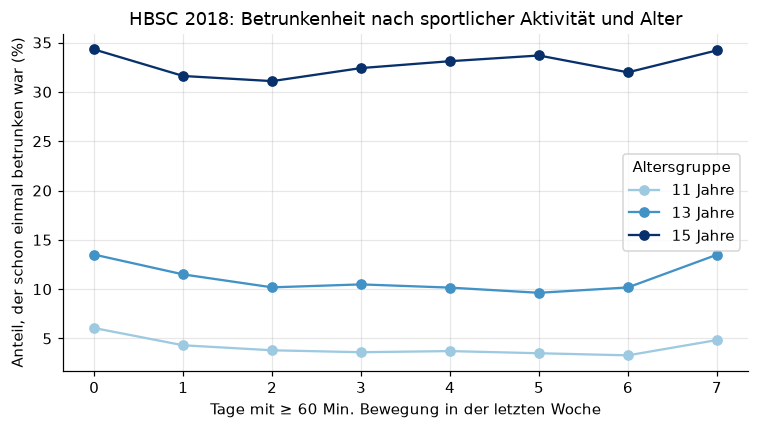

Fallzahl: 218507


In [9]:
h18 = hbsc[hbsc.year == 2018].dropna(subset=["sport_days", "drunk_ever", "agecat"])
tab = (h18.groupby(["agecat", "sport_days"]).drunk_ever.mean().mul(100).unstack(0))
tab.columns = ["11 Jahre", "13 Jahre", "15 Jahre"]

fig, ax = plt.subplots(figsize=(7, 4))
for c, col in zip(tab.columns, ["#9ecae1", "#4292c6", "#08306b"]):
    ax.plot(tab.index, tab[c], marker="o", color=col, label=c)
ax.set_xlabel("Tage mit ≥ 60 Min. Bewegung in der letzten Woche")
ax.set_ylabel("Anteil, der schon einmal betrunken war (%)")
ax.set_title("HBSC 2018: Betrunkenheit nach sportlicher Aktivität und Alter")
ax.legend(title="Altersgruppe"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Fallzahl:", len(h18))

### b) Heatmap: Verteilung der Betrunkenheit je Sportgruppe (alle Wellen)

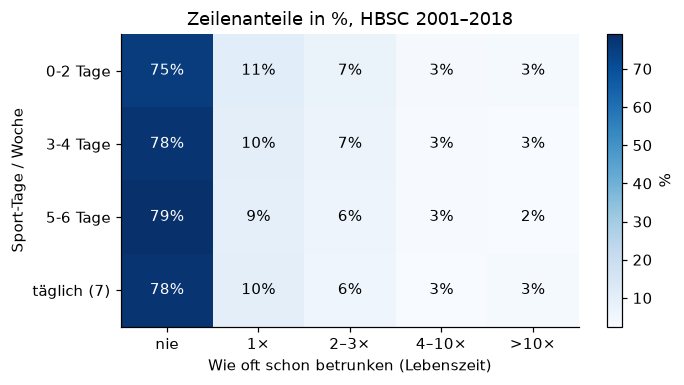

In [10]:
labels_d = {1: "nie", 2: "1×", 3: "2–3×", 4: "4–10×", 5: ">10×"}
ct = pd.crosstab(both.sport_gruppe, both.drunk_lifetime, normalize="index").mul(100).rename(columns=labels_d)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
im = ax.imshow(ct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(ct.shape[1]), ct.columns); ax.set_yticks(range(ct.shape[0]), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.values[i, j]:.0f}%", ha="center", va="center",
                color="white" if ct.values[i, j] > 45 else "black")
ax.set_xlabel("Wie oft schon betrunken (Lebenszeit)"); ax.set_ylabel("Sport-Tage / Woche")
ax.set_title("Zeilenanteile in %, HBSC 2001–2018"); plt.colorbar(im, label="%")
plt.tight_layout(); plt.show()

### c) Länderebene: Sport vs. Alkohol (Streudiagramm, 2018)

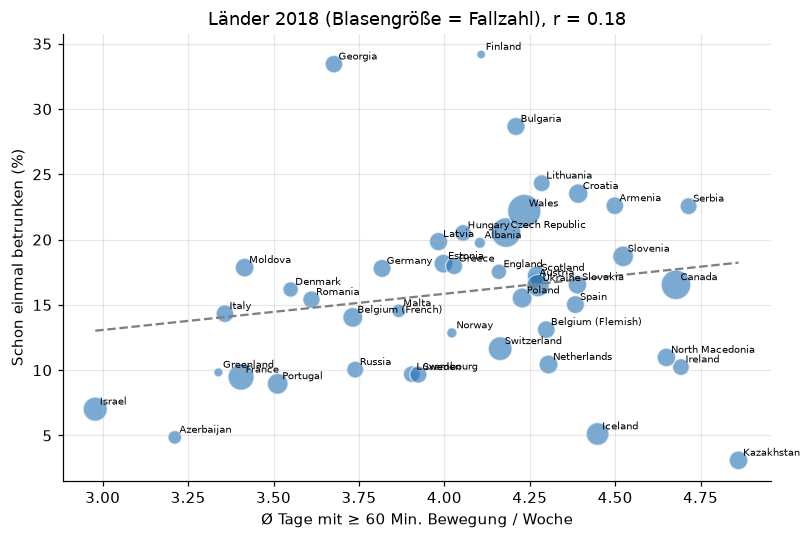

46 Länder, Pearson r = 0.18


In [11]:
land = (h18.groupby("country").agg(sport=("sport_days", "mean"), betrunken=("drunk_ever", "mean"), n=("sport_days", "size")))
land["betrunken"] *= 100
land = land[land.n >= 500]
r = land.sport.corr(land.betrunken)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(land.sport, land.betrunken, s=land.n / 30, alpha=.6, color="#2171b5", edgecolor="white")
for name, row in land.iterrows():
    ax.annotate(name, (row.sport, row.betrunken), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
m, b = np.polyfit(land.sport, land.betrunken, 1)
xs = np.linspace(land.sport.min(), land.sport.max(), 20); ax.plot(xs, m * xs + b, "--", color="grey")
ax.set_xlabel("Ø Tage mit ≥ 60 Min. Bewegung / Woche"); ax.set_ylabel("Schon einmal betrunken (%)")
ax.set_title(f"Länder 2018 (Blasengröße = Fallzahl), r = {r:.2f}"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"{len(land)} Länder, Pearson r = {r:.2f}")

### d) Zeitverlauf: Entwickeln sich Sport und Alkohol gegenläufig?

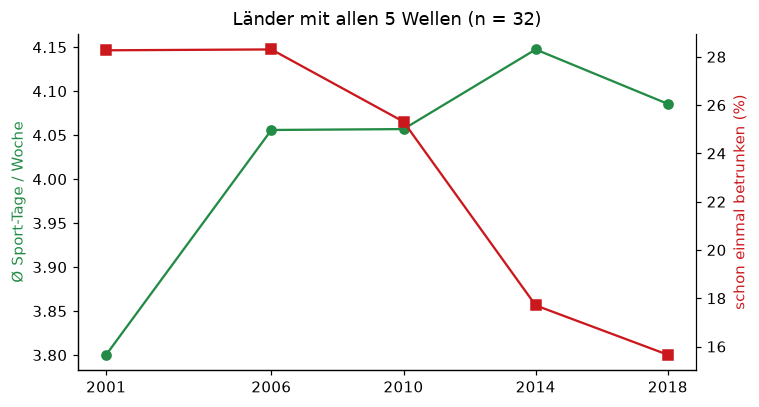

      sport  betrunken
year                  
2001   3.80      28.27
2006   4.06      28.30
2010   4.06      25.31
2014   4.15      17.70
2018   4.09      15.66


In [12]:
alle5 = hbsc.groupby("country").year.nunique().pipe(lambda s: s[s == 5].index)
zeit = (hbsc[hbsc.country.isin(alle5)].groupby("year")
        .agg(sport=("sport_days", "mean"), betrunken=("drunk_ever", "mean")))
zeit["betrunken"] *= 100

fig, ax1 = plt.subplots(figsize=(7, 3.8))
ax1.plot(zeit.index, zeit.sport, "o-", color="#238b45"); ax1.set_ylabel("Ø Sport-Tage / Woche", color="#238b45")
ax2 = ax1.twinx(); ax2.spines["right"].set_visible(True)
ax2.plot(zeit.index, zeit.betrunken, "s-", color="#cb181d"); ax2.set_ylabel("schon einmal betrunken (%)", color="#cb181d")
ax1.set_xticks(zeit.index); ax1.set_title(f"Länder mit allen 5 Wellen (n = {len(alle5)})")
plt.tight_layout(); plt.show()
print(zeit.round(2).to_string())

### Was die Grafiken zeigen

- **Personenebene (a, b):** Der Zusammenhang zwischen Sport und Betrunkenheit ist **sehr schwach** (Spearman ≈ −0,03 in allen Wellen).
  Viel stärker wirkt das **Alter**: 2018 waren rund 5 % der 11-Jährigen, ≈ 10 % der 13-Jährigen und ≈ 33 % der 15-Jährigen schon einmal betrunken – fast unabhängig von den Sporttagen.
  Die Kurve ist leicht **U-förmig** (höher bei 0 und bei 7 Sporttagen als dazwischen) – ein Hinweis, dass einfache lineare Zusammenhänge nicht ausreichen.
- **Länderebene (c):** Länder mit mehr Bewegung haben eher etwas *mehr* Betrunkenheit (r ≈ +0,18) – mit großer Streuung (z. B. Kasachstan/Island: viel Sport, wenig Alkohol; Georgien/Finnland: mittlerer Sport, viel Alkohol).
- **Zeitverlauf (d):** Die sportliche Aktivität ist über 17 Jahre nahezu konstant (≈ 3,8 → 4,1 Tage), der Anteil „schon einmal betrunken“ **sinkt deutlich** (≈ 28 % → 16 %).
  Beide Größen entwickeln sich also nicht gegenläufig – Alkoholkonsum verändert sich stärker als das Sportverhalten.

Damit ist die Fragestellung auch **visuell interessant**: Ein erwartetes „mehr Sport = weniger Alkohol“ bestätigt sich nicht einfach, und genau das lässt sich nur mit Gruppierung (Alter, Geschlecht, Land) sinnvoll erkunden.

---
## Fazit: Ist der Datensatz tauglich?

**Ja – der Datensatz erfüllt die Anforderungen der Aufgabe und eignet sich gut für den Vergleich Alkohol vs. Sport.**

| Kriterium | Bewertung |
|---|---|
| Größe | ≈ 1,04 Mio. Befragte in 5 Wellen, 120–170 Spalten – sehr groß, muss aggregiert visualisiert werden |
| Multivariat | Sport, Alkohol (Lebenszeit + 30 Tage), Alter, Geschlecht, Land, Jahr + optional Ernährung, Rauchen, Wohlbefinden |
| Attributtypen | nominal (Land, Geschlecht), ordinal (Betrunkenheit, Altersgruppe), quantitativ (Sporttage) → Frage 8 erfüllt |
| Semantische Strukturen | temporal (5 Wellen) + geografisch (48 Länder) + hierarchisch (Land → Schule → Klasse → Person) |
| Datentransformation nötig | ja, sinnvoll: Harmonisierung der Wellen, Codes → NaN, Gruppierung von Sporttagen, Aggregation je Land/Alter |
| Fragen mit visueller Analyse | ja: Zusammenhang je Altersgruppe, Länderstreuung, Trend über Zeit – das Ergebnis ist nicht trivial |
| Datenqualität | gut, aber uneinheitliche Wellen (Namen, Trennzeichen, Kodierung, Sondercodes); nach `harmonisieren()` konsistent |
| Zugang | frei (Open-Access-Versionen), CSV, Codebücher als PDF; Nutzungsbedingungen im Codebuch beachten |

**Vor der Analyse zu erledigen:**
1. `harmonisieren()` anwenden: 5 Dateien vereinheitlichen, `-99`/Leerzeichen → NaN, Dezimalkomma bei `age` 2018 beachten.
2. Alkohol-Variable festlegen: `drunk_lifetime` gilt für alle 5 Wellen; `alc_30d` nur 2010–2018 (2010 andere Antwortskala als 2014/2018 – vorsichtig vergleichen).
3. Für Zeitvergleiche auf die 32 Länder mit allen 5 Wellen einschränken; Spanien und Türkei haben 2006 keine `drunk`-Daten.
4. Auswertungen sind **ungewichtet** (Gewichte nicht in allen Wellen vorhanden) und zeigen Zusammenhänge, keine Ursachen.

**Mögliche Fragestellungen für Frage 5** (alle brauchen visuelle Analyse, nicht nur min/max):
- Unterscheidet sich der Zusammenhang Sport ↔ Alkohol nach Alter und Geschlecht? (Small Multiples, Heatmap)
- Welche Länder weichen vom Muster ab („viel Sport, wenig Alkohol“ vs. umgekehrt)? (Streudiagramm, Karte)
- Hat sich der Alkoholkonsum in 17 Jahren stärker verändert als das Sportverhalten – und in welchen Ländern? (Slopegraph, Zeitreihen)
- Gibt es die U-Form (viel Sport und viel Alkohol bei Jugendlichen in Vereinen?) nur bei bestimmten Gruppen? (Heatmap je Geschlecht/Alter)